# Lab 04 - Segmentation & Image Restoration 

#### E/21/087 - Dewagedara D.M.E.S.

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

img = cv2.imread('Efac.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

## Task 01 - Threshold for Foreground/Background Separation 

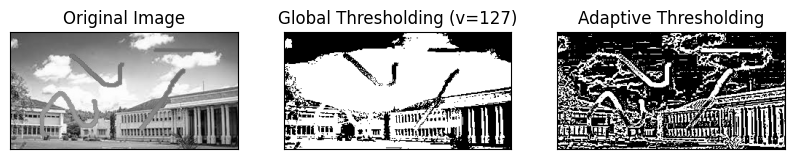

In [11]:
# Global Thresholding
ret, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
# Adaptive Tresholding
adaptive_thr = cv2.adaptiveThreshold(gray, 255,1,1,11,2)

titles = ['Original Image', 'Global Thresholding (v=127)', 'Adaptive Thresholding']
images = [gray, global_thresh, adaptive_thr]

plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], 'gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()

#### Answer -

##### Why Uneven Lighting Breaks Naive Thresholding
Naive (Global) thresholding uses a single, fixed intensity value (for example, 127) to classify every pixel in the image as either foreground (white) or background (black).

This approach fails on uneven lighting or textured surfaces for the following reasons:

- **Intensity Variance:** In an image with uneven lighting(such as shadows across part of the scene), the background pixels in the shadowed area might be darker than the foreground pixels in the bright area. A single global threshold cannot separate both simultaneously; it will either make the shadow black (losing the background) or the bright text white (losing the foreground).

- **Lack of Local Context:** Global thresholding looks at the pixel in isolation relative to the global constant. It ignores the neighborhood.

- **Texture Noise:** On textured surfaces (like wood grain or carpet), distinct high-contrast patterns exist locally. A global threshold might pick up the darker parts of the grain as objects, creating significant noise.

##### Why Adaptive Thresholding Works:
Adaptive thresholding calculates the threshold for a pixel based on a small region around it (the block size, e.g., 11x11). This allows it to handle local variations. If a shadow darkens a region, the local threshold lowers automatically, preserving the separation between the foreground and the darkened background.

## Task 2 - K-Means Pixel Clustering

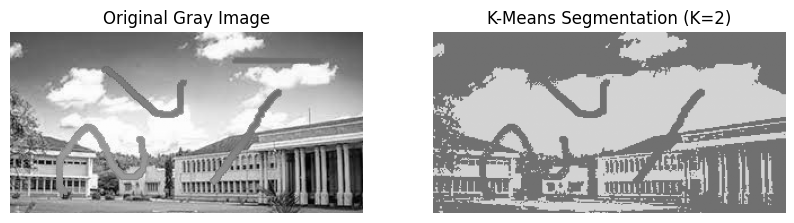

In [13]:
Z = gray.reshape(-1, 1).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
# Apply K-Means
K = 2
ret, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]

segmented_image = res.reshape((gray.shape))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Gray Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='gray',vmin=0,vmax=255)
plt.title(f'K-Means Segmentation (K={K})')
plt.axis('off')

plt.show()

### Answer - 

#### How Intensity Grouping Supports Separation :

K-Means achieves separation without "semantic understanding"by relying purely on statistical grouping of pixel data.

- ***Intensity-Based Grouping:*** The algorithm treats the image as a collection of numerical values (pixel intensities). In the case of dark scribbles on light paper, the pixel values naturally form two distinct clusters on a one-dimensional intensity scale: one cluster with low values representing the dark scribbles and another with high values representing the light background.
- ***Centroids act as Magnets:*** The algorithm places **K** centroids (center points) and iteratively moves them until they sit at the center of these data clouds.
- ***No Prior Knowledge Required:*** Unlike supervised models such as neural networks, which are trained to recognize specific objects or patterns, K-Means has no understanding of shape, context, or meaning. Separation occurs solely because the scribbles exhibit intensity values that are statistically different from the surrounding background. If the scribbles had the same intensity as the background, K-Means would fail to distinguish them.


#### Why this helps isolate damage :

Image damage such as scratches, ink spills, or scribbles typically introduces strong intensity contrast relative to the clean background. By clustering all pixels into two groups, K-Means suppresses smooth intensity variations and minor noise, resulting in a binary segmentation where damaged regions appear as a distinct cluster. This makes the damaged areas easier to isolate and analyze.

## Task 3 — Edge Map for Structure Protection 

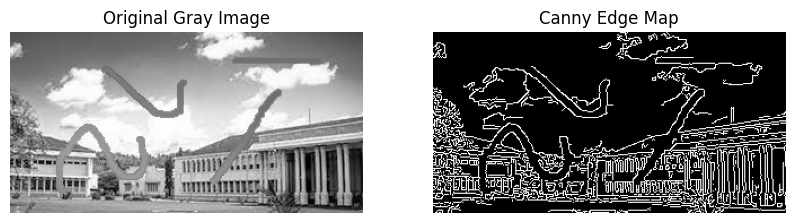

In [15]:
edges = cv2.Canny(gray, 80, 160)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Gray Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Map')
plt.axis('off')

plt.show()

#### Answer -

Canny edge detection relies on intensity gradients, identifying sharp changes in brightness. It does not have semantic understanding and therefore cannot distinguish between a building corner and a crayon mark; however, their edge characteristics often differ significantly.

**1. True Scene Structure**

- Characteristics: These edges correspond to physical boundaries of real objects in the scene, such as the outline of a doorway, object contours, text edges, or the horizon.T

- Detection: In the edge map, true structural edges typically appear as long, smooth, and continuous contours. Since structural boundaries usually involve consistent changes in illumination or material properties, they often generate strong gradients that exceed the upper hysteresis threshold (e.g., > 160), ensuring stable detection.

***2. Scribble Strokes / Damage***

- Characteristics: Scribbles are surface-level noise. They are often erratic, high-frequency, and random in direction.

- Detection: In the edge map, these appear as jagged, clustered, or chaotic segments.

    - High Contrast: If the scribble is dark ink on light paper, Canny will detect it aggressively because the gradient is very steep.

    - Texture: If the damage is a texture (like a scuff mark), it may produce many small, disconnected edge fragments.

## Task 4 - Mask and Inpaint Damaged Regions

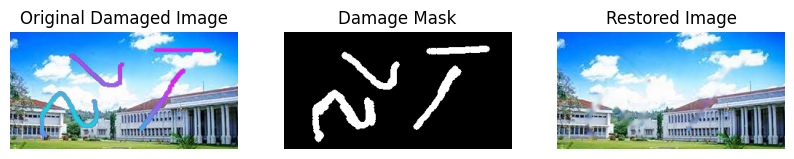

In [8]:
# Manually created mask (grayscale)
mask = cv2.imread('manual_mask.png', 0)

# Step 2: Apply inpainting using the mask
restored_img = cv2.inpaint(img, mask, inpaintRadius=3, flags=cv2.INPAINT_NS)

plt.figure(figsize=(10, 5))


plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Damaged Image")
plt.axis('off')


plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("Damage Mask")
plt.axis('off')


plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(restored_img, cv2.COLOR_BGR2RGB))
plt.title("Restored Image")
plt.axis('off')
plt.show()

#### Reflection on Realism

***1. How it works (The Telea Method):*** The algorithm starts from the boundary of the mask and works its way inward. It fills the damaged pixels by computing a weighted average of the known pixels in the immediate neighborhood. It essentially "smooths" the surrounding colors into the gap.

***2. Does the fill blend?***

- Success Cases: It blends very well for small scratches, dust spots, or thin lines on homogeneous backgrounds (like a blue sky, a flat wall, or smooth skin). The gradient propagation makes the repair nearly invisible.

- Failure Cases: It often looks artificial for large areas or complex textures.

    - Blurriness: Because it uses averaging, large gaps result in a "blurry blob" rather than recreated detail.

    - Structure Loss: If a scribble covers an edge (like the frame of a pair of glasses), the algorithm doesn't know how to reconnect the broken line; it just smudges the color across, often breaking the object's geometry.

### Final Reflection

#### 1. Segmentation as the Foundation for Inpainting
Inpainting algorithms are "blind" without a map. They cannot distinguish between a valuable detail and a defect on their own.

 - Creating the "Hit List" :  Segmentation (whether through Thresholding, K-Means, or Deep Learning) generates the binary Mask. This mask tells the inpainting algorithm exactly which pixels are invalid.

 - Precision Matters :  If the segmentation is too aggressive, you erase valid image data (e.g., removing a mole when you only wanted to remove a scratch). If it is too conservative, artifacts of the damage remain, resulting in a "halo" of noise around the restored area.

  - Automated Workflow :  Without effective segmentation, restoration is a manual, pixel-by-pixel labor. Segmentation scales the process, allowing for the automatic cleaning of thousands of frames in a video or pages in a scanned archive.

#### 2. Why Edge Protection is Crucial
The human eye is incredibly sensitive to edges. We can tolerate slightly "wrong" colors in a restored area, but we immediately notice if a straight line becomes jagged or if a continuous curve is broken.

- Structural Integrity :  Edge protection ensures that the "bones" of the image remain intact. When inpainting a scratch that crosses a window frame, edge protection ensures the vertical line of the frame is reconnected, rather than smeared into a blur.

- Preventing "Bleed" :  Inpainting works by averaging neighboring pixels. Without edge awareness, a dark object next to a bright background will "bleed" into the repaired area, creating a smudge. Edge-aware techniques (like Navier-Stokes) use the direction of gradients (isophotes) to ensure colors flow along edges rather than across them.